# 02_baseline — Role B: Baseline & Tree Analysis

Mục tiêu: huấn luyện cây quyết định baseline M0 không giới hạn, đánh giá đầy đủ trên split chung, trực quan hóa cây, giải thích các node đầu, đo độ phức tạp, trích luật IF-THEN và kiểm tra phụ Gini so với Entropy.

## 1. Import và xác định repo root

Notebook tìm repo bằng marker `src/data.py`, vì vậy có thể chạy từ repo root, thư mục `notebooks/`, VS Code hoặc `nbconvert`.

In [10]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Image, display
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

def find_repo_root(start: Path | None = None) -> Path:
    """Find the nearest ancestor containing the shared data pipeline."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "data.py").is_file():
            return candidate
    raise FileNotFoundError("Không tìm thấy repo root chứa src/data.py")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data import get_train_test
from src.evaluate import RESULT_COLUMNS, evaluate_model
from src.visualize import export_rules, plot_tree_figure

FIGURES_DIR = REPO_ROOT / "figures"
OUTPUTS_DIR = REPO_ROOT / "outputs"
print(f"Repo root detected: {REPO_ROOT.name}")

Repo root detected: Lab2_DecisionTree


## 2. Dữ liệu và split chung

Đây là lần gọi duy nhất tới `get_train_test()`. Notebook không tự load, scale hay chia lại dữ liệu.

In [11]:
X_train, X_test, y_train, y_test = get_train_test()

In [12]:
assert X_train.shape[1] == X_test.shape[1] == 90, "Pipeline phải tạo đúng 90 feature sau one-hot"
assert set(y_train.unique()) == set(y_test.unique()) == {"Dropout", "Enrolled", "Graduate"}

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Số feature sau one-hot: {X_train.shape[1]}")

class_distribution = pd.DataFrame({
    "train_n": y_train.value_counts().reindex(["Dropout", "Enrolled", "Graduate"]),
    "train_pct": y_train.value_counts(normalize=True).reindex(["Dropout", "Enrolled", "Graduate"]),
    "test_n": y_test.value_counts().reindex(["Dropout", "Enrolled", "Graduate"]),
    "test_pct": y_test.value_counts(normalize=True).reindex(["Dropout", "Enrolled", "Graduate"]),
})
class_distribution_style = (
    class_distribution.style
    .format({"train_pct": "{:.2%}", "test_pct": "{:.2%}"})
    .set_uuid("class-distribution")
)
display(HTML(class_distribution_style.to_html()))

Train shape: (3539, 90)
Test shape:  (885, 90)
Số feature sau one-hot: 90


,train_n,train_pct,test_n,test_pct
Target,,,,
Dropout,1137,32.13%,284,32.09%
Enrolled,635,17.94%,159,17.97%
Graduate,1767,49.93%,442,49.94%


## 3. Huấn luyện M0 baseline

M0 dùng đúng `DecisionTreeClassifier(random_state=42)`: criterion Gini mặc định, không giới hạn depth/split/leaf, không pruning.

In [13]:
m0 = DecisionTreeClassifier(random_state=42)
m0.fit(X_train, y_train)
m0_runtime_params = m0.get_params(deep=False)
stable_param_keys = (
    "ccp_alpha", "class_weight", "criterion", "max_depth",
    "max_features", "max_leaf_nodes", "min_impurity_decrease",
    "min_samples_leaf", "min_samples_split", "min_weight_fraction_leaf",
    "random_state", "splitter",
)
m0_stable_params = {key: m0_runtime_params[key] for key in stable_param_keys}

train_acc = accuracy_score(y_train, m0.predict(X_train))
test_acc = accuracy_score(y_test, m0.predict(X_test))
error_rate = 1.0 - test_acc

print("Model parameters:")
print(m0_runtime_params)
print(f"Train accuracy: {train_acc:.6f}")
print(f"Test accuracy:  {test_acc:.6f}")
print(f"Error rate:     {error_rate:.6f}")
print(f"Tree depth:     {m0.get_depth()}")
print(f"Number leaves:  {m0.get_n_leaves()}")

assert m0_runtime_params["criterion"] == "gini"
assert m0_runtime_params["max_depth"] is None
assert m0_runtime_params["ccp_alpha"] == 0.0
assert 0.65 <= test_acc <= 0.72, "Test accuracy ngoài vùng kỳ vọng; cần kiểm tra pipeline"
assert test_acc <= 0.90, "Test accuracy bất thường; nghi ngờ leakage"

Model parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Train accuracy: 1.000000
Test accuracy:  0.668927
Error rate:     0.331073
Tree depth:     27
Number leaves:  634


## 4. Đánh giá đầy đủ và lưu artifact

`evaluate_model()` tính đủ schema 16 cột, ROC-AUC macro OVR từ `predict_proba`, recall theo tên lớp, và chỉ append M0 khi chưa tồn tại.

In [14]:
m0_result = evaluate_model(
    m0,
    X_train,
    y_train,
    X_test,
    y_test,
    model_id="M0",
    model_name="Baseline Decision Tree (Gini)",
    params=m0_stable_params,
    author="B",
    classification_report_path=OUTPUTS_DIR / "classification_report_M0.txt",
    confusion_matrix_path=FIGURES_DIR / "B_cm_M0.png",
)
assert list(m0_result) == RESULT_COLUMNS
assert np.isclose(m0_result["error_rate"], 1.0 - m0_result["test_acc"])
display(pd.DataFrame([m0_result]))

,model_id,model_name,params,train_acc,test_acc,error_rate,precision_macro,recall_macro,f1_macro,roc_auc_macro,recall_dropout,recall_enrolled,recall_graduate,tree_depth,n_leaves,author
0,M0,Baseline Decision Tree (Gini),"{""ccp_alpha"":0.0,""class_weight"":null,""criterio...",1.0,0.668927,0.331073,0.607642,0.60931,0.608271,0.719456,0.679577,0.383648,0.764706,27,634,B


              precision    recall  f1-score   support

     Dropout     0.6820    0.6796    0.6808       284
    Enrolled     0.3567    0.3836    0.3697       159
    Graduate     0.7842    0.7647    0.7743       442

    accuracy                         0.6689       885
   macro avg     0.6076    0.6093    0.6083       885
weighted avg     0.6746    0.6689    0.6716       885



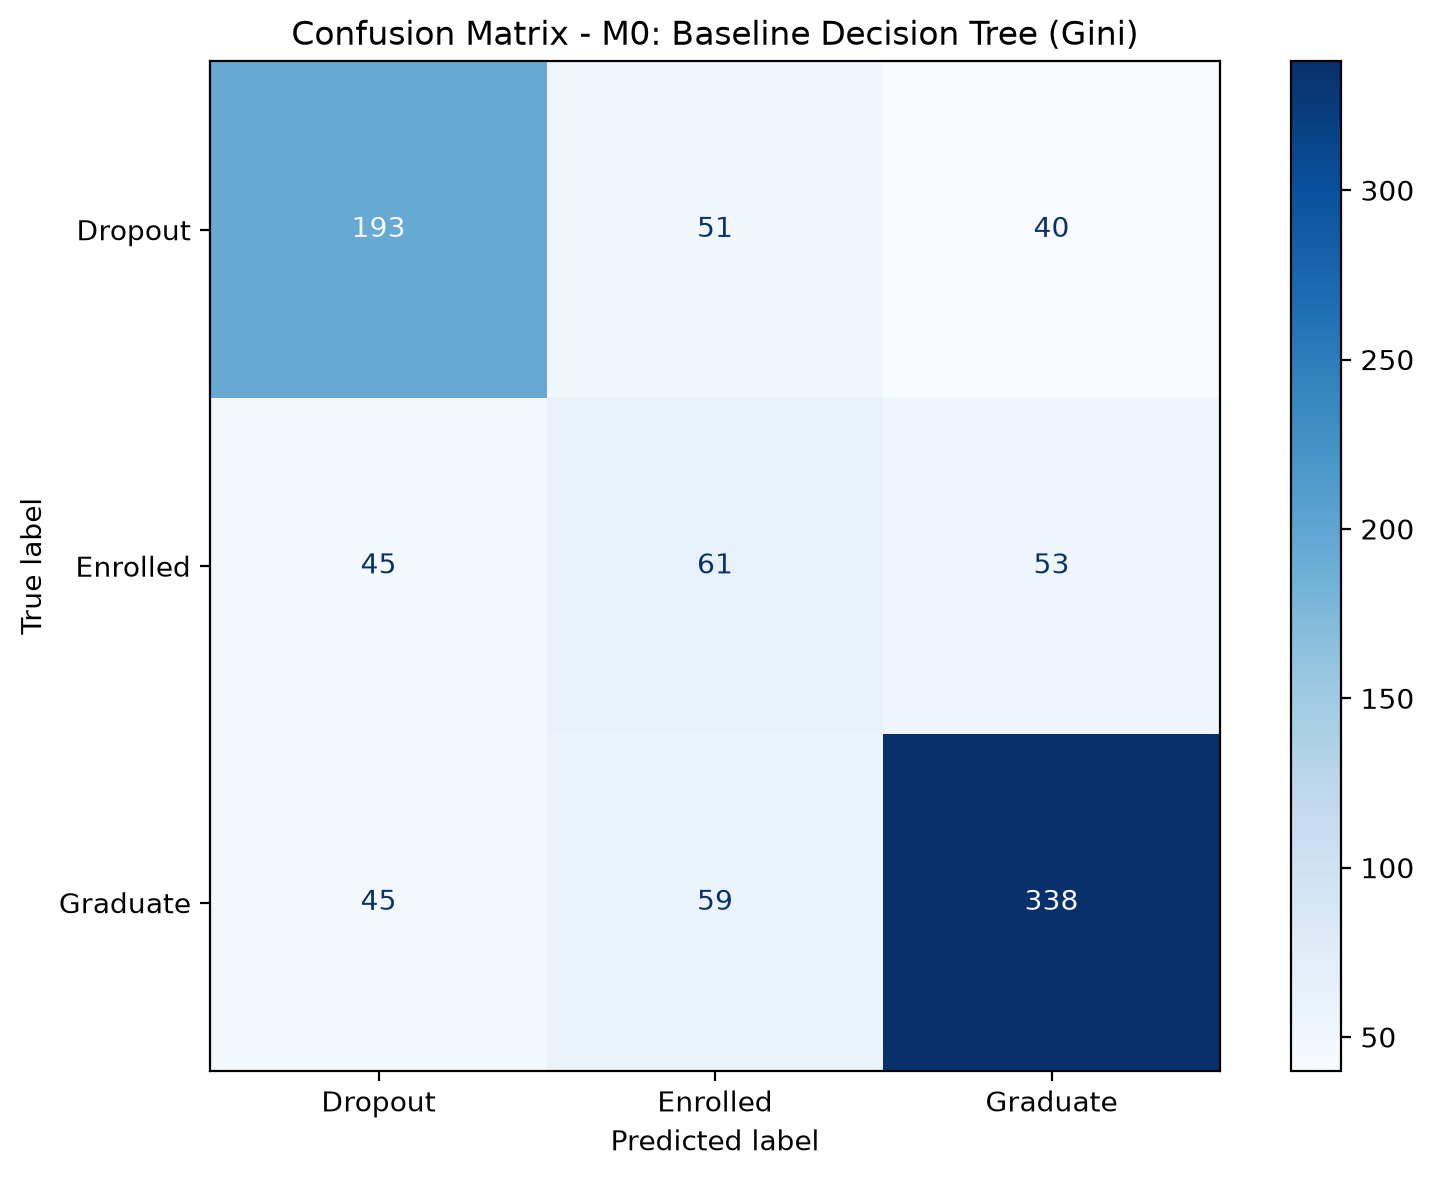

In [15]:
print((OUTPUTS_DIR / "classification_report_M0.txt").read_text(encoding="utf-8"))
display(Image(filename=str(FIGURES_DIR / "B_cm_M0.png"), width=700))

## 5. Xuất cây đầy đủ, cây top-3 và toàn bộ luật

Cây đầy đủ dùng để minh họa độ rối/overfitting; cây top-3 dùng để đọc các split đầu. `max_depth=3` ở đây chỉ giới hạn phần hiển thị, không thay đổi M0.

B_tree_M0_full.png: 3,114,978 bytes
B_tree_M0_top3.png: 551,521 bytes
rules_M0.txt: 173,976 bytes


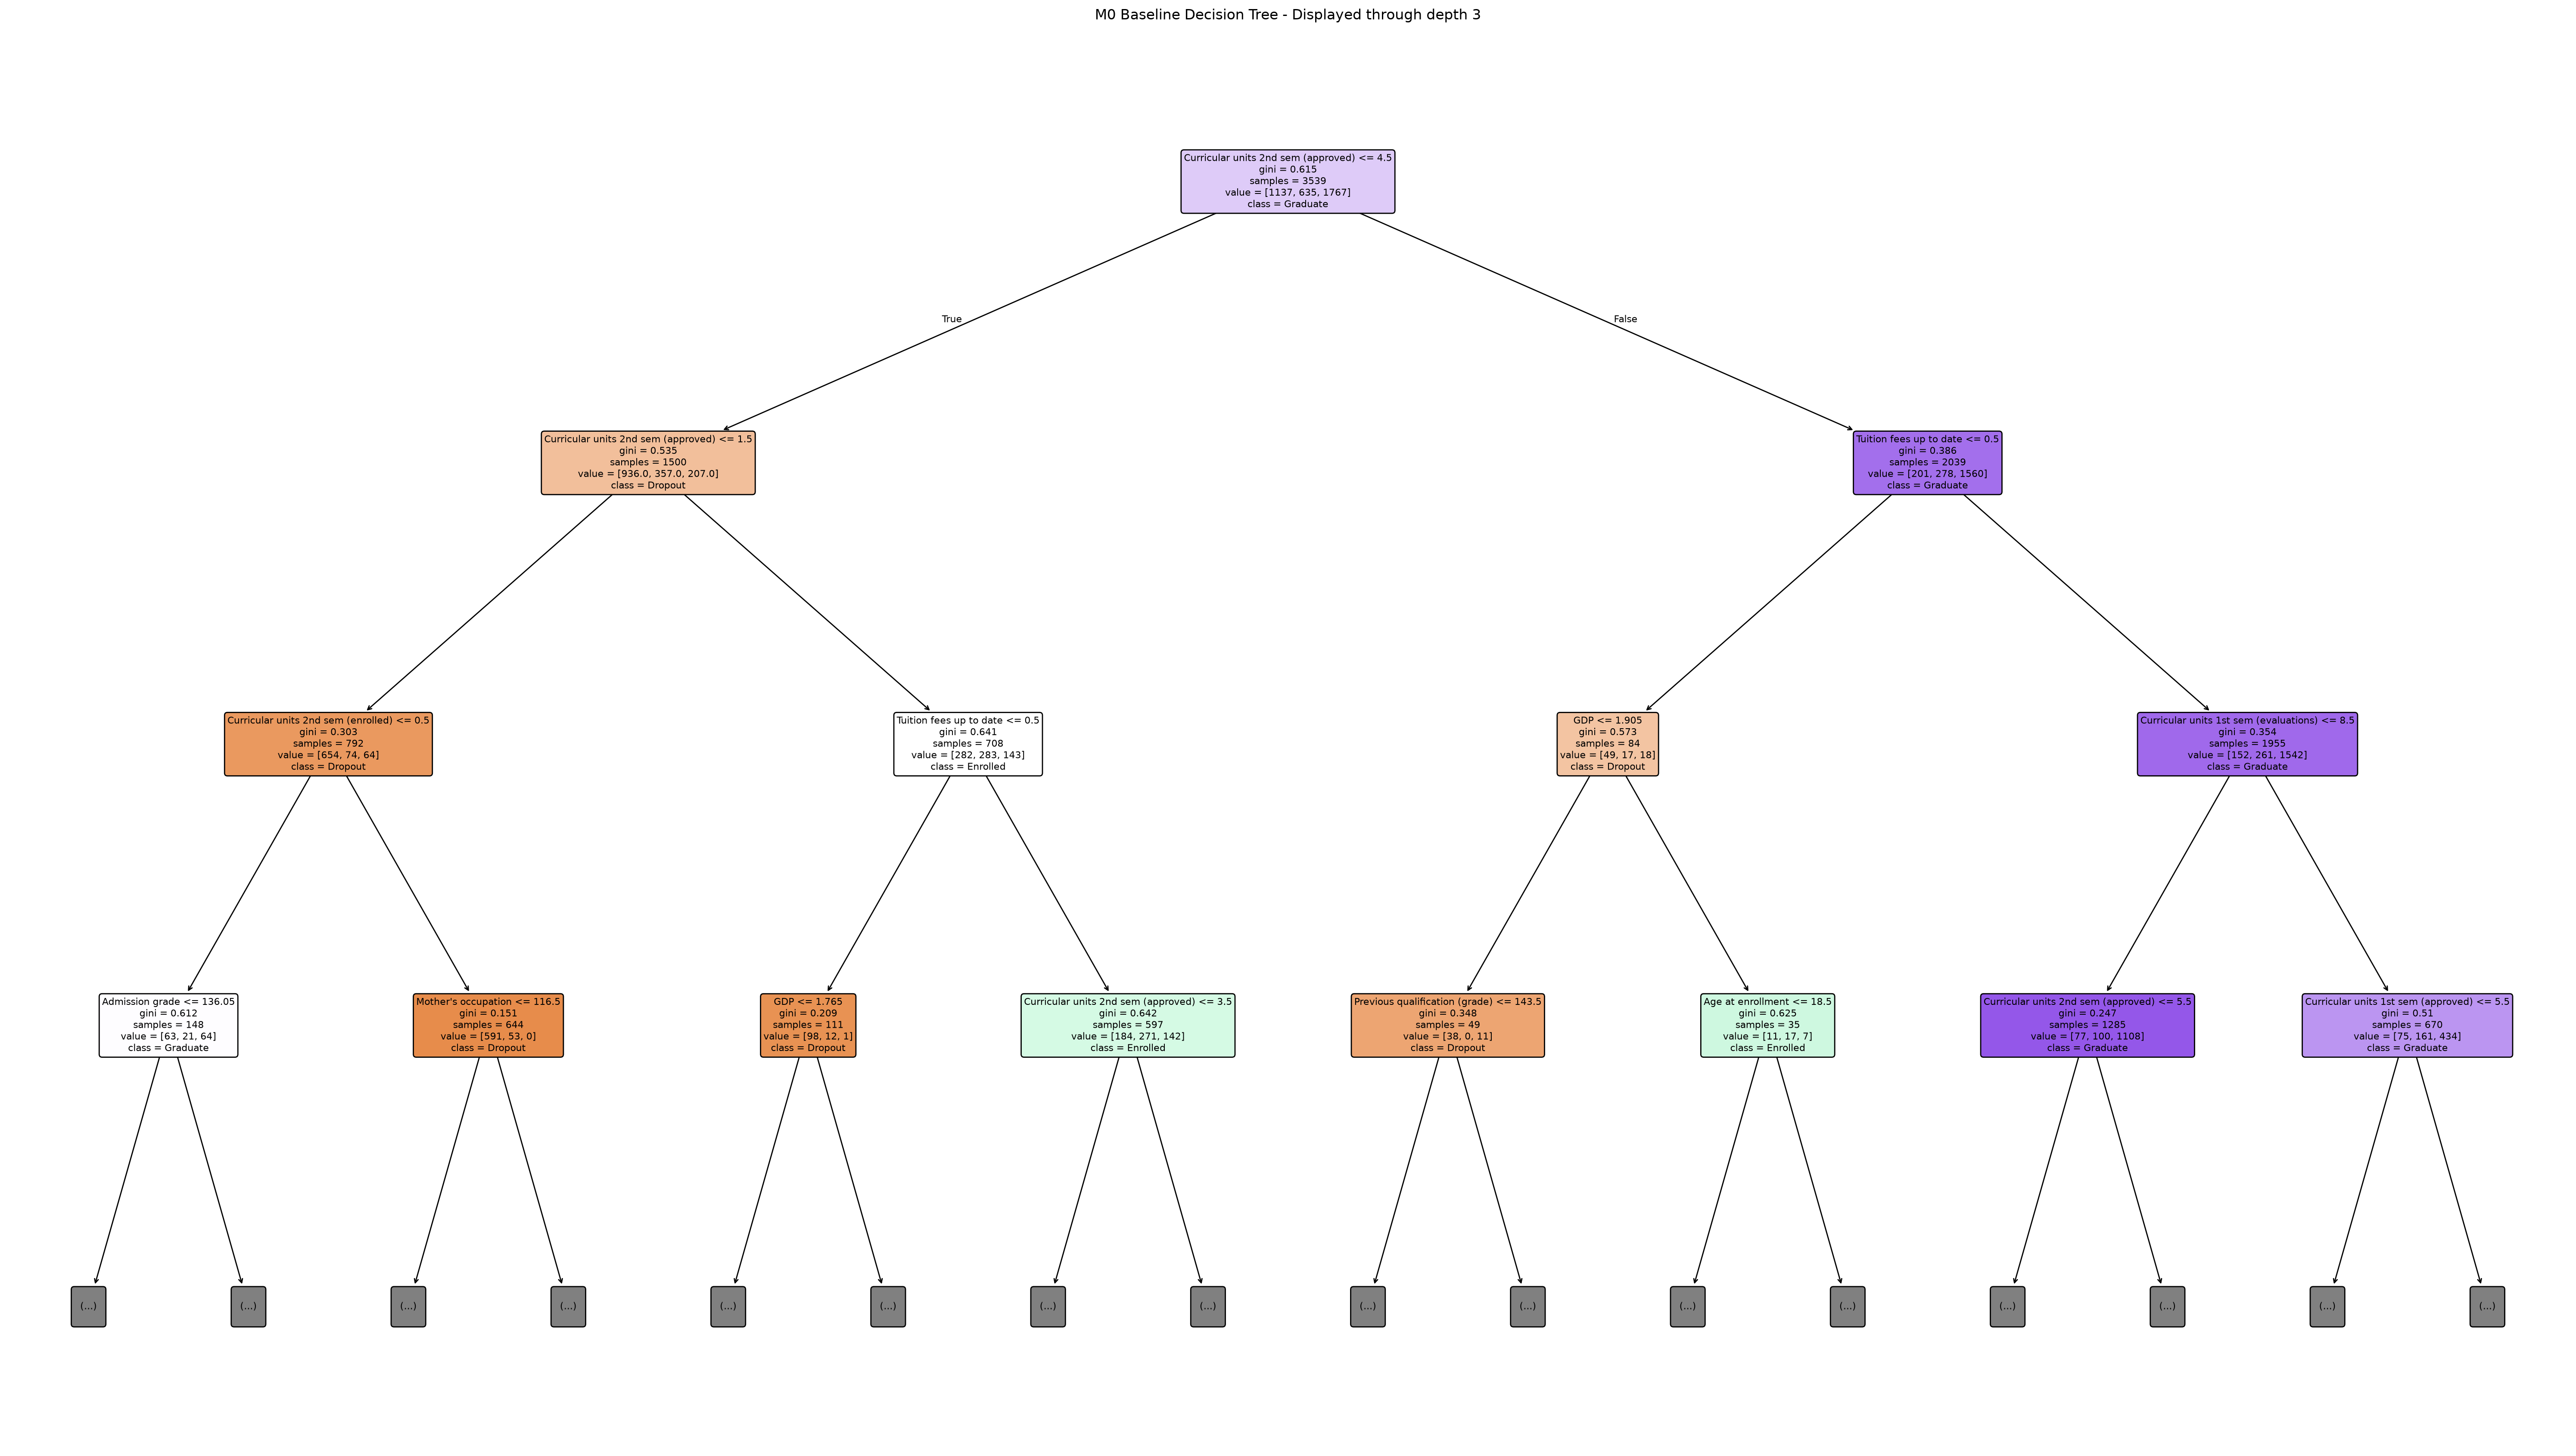

In [16]:
full_tree_path = plot_tree_figure(
    m0,
    X_train.columns,
    m0.classes_,
    FIGURES_DIR / "B_tree_M0_full.png",
    figsize=(48, 30),
    dpi=150,
    fontsize=2,
    title="M0 Baseline Decision Tree - Full (unrestricted)",
)
top3_tree_path = plot_tree_figure(
    m0,
    X_train.columns,
    m0.classes_,
    FIGURES_DIR / "B_tree_M0_top3.png",
    max_depth=3,
    figsize=(30, 17),
    dpi=200,
    fontsize=8,
    title="M0 Baseline Decision Tree - Displayed through depth 3",
)
rules_path = export_rules(m0, X_train.columns, OUTPUTS_DIR / "rules_M0.txt")

for artifact in (full_tree_path, top3_tree_path, rules_path):
    print(f"{artifact.name}: {artifact.stat().st_size:,} bytes")
display(Image(filename=str(top3_tree_path), width=1200))

## 6. Feature importance

,importance
Curricular units 2nd sem (approved),0.3404
Curricular units 2nd sem (grade),0.0453
Tuition fees up to date,0.0452
Curricular units 2nd sem (enrolled),0.0450
Admission grade,0.0444
Curricular units 1st sem (evaluations),0.0335
Previous qualification (grade),0.0308
Curricular units 1st sem (approved),0.0288
Mother's occupation,0.0283
Curricular units 1st sem (grade),0.0281


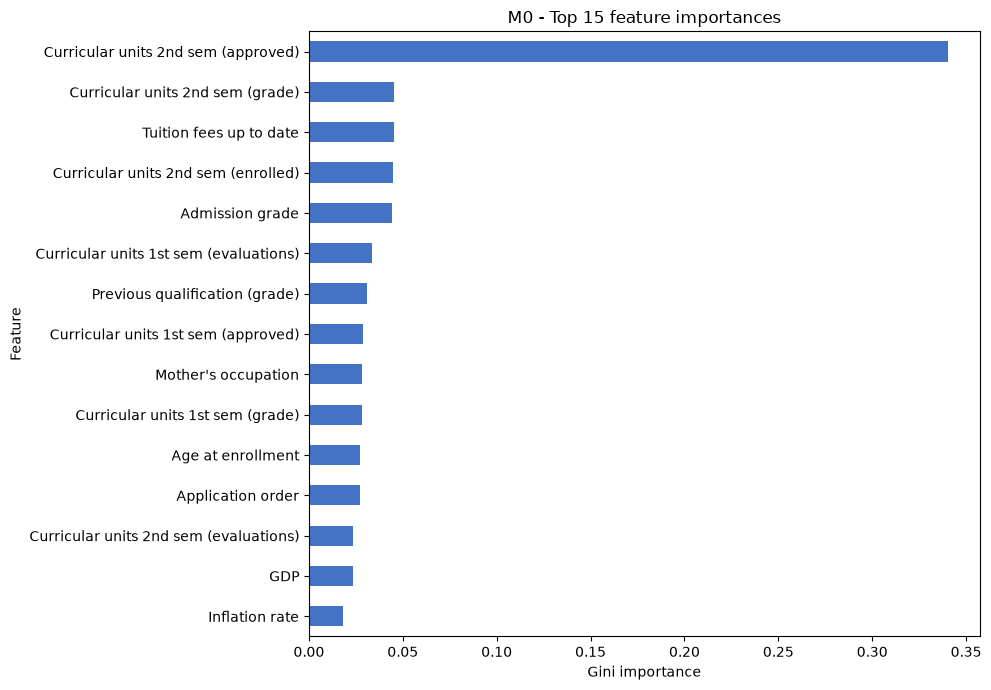

In [17]:
feature_importance = (
    pd.Series(m0.feature_importances_, index=X_train.columns, name="importance")
    .sort_values(ascending=False)
    .head(15)
)
feature_importance_style = (
    feature_importance.to_frame().style
    .format({"importance": "{:.4f}"})
    .set_uuid("feature-importance")
)
display(HTML(feature_importance_style.to_html()))

axis = feature_importance.sort_values().plot.barh(figsize=(10, 7), color="#4472C4")
axis.set_title("M0 - Top 15 feature importances")
axis.set_xlabel("Gini importance")
axis.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Root split và ba tầng đầu

Các phân bố dưới đây theo đúng thứ tự `m0.classes_`, không hard-code vị trí lớp. Gini giảm được tính theo trọng số số mẫu của hai node con.

In [18]:
tree = m0.tree_
feature_names = np.asarray(X_train.columns, dtype=object)
class_names = np.asarray(m0.classes_, dtype=object)

def node_class_counts(node_id: int) -> np.ndarray:
    """Recover integer class counts from sklearn's normalized tree values."""
    weighted_n = tree.weighted_n_node_samples[node_id]
    return np.rint(tree.value[node_id][0] * weighted_n).astype(int)

root = 0
left = tree.children_left[root]
right = tree.children_right[root]
root_n = tree.n_node_samples[root]
weighted_gini_after = (
    tree.n_node_samples[left] / root_n * tree.impurity[left]
    + tree.n_node_samples[right] / root_n * tree.impurity[right]
)
gini_reduction = tree.impurity[root] - weighted_gini_after
root_feature = feature_names[tree.feature[root]]
root_threshold = tree.threshold[root]

root_analysis = pd.Series({
    "feature": root_feature,
    "threshold": root_threshold,
    "root_n": root_n,
    "root_distribution": dict(zip(class_names, node_class_counts(root))),
    "left_n": tree.n_node_samples[left],
    "left_distribution": dict(zip(class_names, node_class_counts(left))),
    "right_n": tree.n_node_samples[right],
    "right_distribution": dict(zip(class_names, node_class_counts(right))),
    "gini_before": tree.impurity[root],
    "weighted_gini_after": weighted_gini_after,
    "weighted_impurity_reduction": gini_reduction,
})
display(root_analysis.to_frame("value"))
print(
    f"CART chọn {root_feature} <= {root_threshold:.3f} vì trong các split ứng viên, "
    f"nó cực đại hóa mức giảm impurity có trọng số tại root: "
    f"{tree.impurity[root]:.6f} - {weighted_gini_after:.6f} = {gini_reduction:.6f}."
)

,value
feature,Curricular units 2nd sem (approved)
threshold,4.5
root_n,3539
root_distribution,"{'Dropout': 1137, 'Enrolled': 635, 'Graduate':..."
left_n,1500
left_distribution,"{'Dropout': 936, 'Enrolled': 357, 'Graduate': ..."
right_n,2039
right_distribution,"{'Dropout': 201, 'Enrolled': 278, 'Graduate': ..."
gini_before,0.615292
weighted_gini_after,0.449325


CART chọn Curricular units 2nd sem (approved) <= 4.500 vì trong các split ứng viên, nó cực đại hóa mức giảm impurity có trọng số tại root: 0.615292 - 0.449325 = 0.165967.


In [19]:
node_depth = np.zeros(tree.node_count, dtype=int)
parent = np.full(tree.node_count, -1, dtype=int)
direction = np.full(tree.node_count, "root", dtype=object)
stack = [0]
while stack:
    node_id = stack.pop()
    for child_id, branch in ((tree.children_left[node_id], "left"), (tree.children_right[node_id], "right")):
        if child_id != -1:
            node_depth[child_id] = node_depth[node_id] + 1
            parent[child_id] = node_id
            direction[child_id] = branch
            stack.append(child_id)

top_rows = []
for node_id in np.flatnonzero(node_depth <= 3):
    counts = node_class_counts(node_id)
    is_leaf = tree.children_left[node_id] == -1
    if node_id == 0:
        arrival = "root"
    else:
        parent_id = parent[node_id]
        parent_feature = feature_names[tree.feature[parent_id]]
        operator = "<=" if direction[node_id] == "left" else ">"
        arrival = f"{parent_feature} {operator} {tree.threshold[parent_id]:.3f}"
    split = (
        "leaf"
        if is_leaf
        else f"{feature_names[tree.feature[node_id]]} <= {tree.threshold[node_id]:.3f}"
    )
    top_rows.append({
        "node": node_id,
        "depth": node_depth[node_id],
        "điều kiện đến node": arrival,
        "split tại node": split,
        "n": tree.n_node_samples[node_id],
        "phân bố lớp": dict(zip(class_names, counts)),
        "gini": tree.impurity[node_id],
        "lớp dự đoán": class_names[np.argmax(counts)],
    })
top_nodes = pd.DataFrame(top_rows).sort_values(["depth", "node"])
top_nodes_style = top_nodes.style.format({"gini": "{:.4f}"}).set_uuid("top-nodes")
display(HTML(top_nodes_style.to_html()))

,node,depth,điều kiện đến node,split tại node,n,phân bố lớp,gini,lớp dự đoán
0,0,0,root,Curricular units 2nd sem (approved) <= 4.500,3539,"{'Dropout': np.int64(1137), 'Enrolled': np.int64(635), 'Graduate': np.int64(1767)}",0.6153,Graduate
1,1,1,Curricular units 2nd sem (approved) <= 4.500,Curricular units 2nd sem (approved) <= 1.500,1500,"{'Dropout': np.int64(936), 'Enrolled': np.int64(357), 'Graduate': np.int64(207)}",0.5349,Dropout
8,552,1,Curricular units 2nd sem (approved) > 4.500,Tuition fees up to date <= 0.500,2039,"{'Dropout': np.int64(201), 'Enrolled': np.int64(278), 'Graduate': np.int64(1560)}",0.3863,Graduate
2,2,2,Curricular units 2nd sem (approved) <= 1.500,Curricular units 2nd sem (enrolled) <= 0.500,792,"{'Dropout': np.int64(654), 'Enrolled': np.int64(74), 'Graduate': np.int64(64)}",0.3029,Dropout
5,213,2,Curricular units 2nd sem (approved) > 1.500,Tuition fees up to date <= 0.500,708,"{'Dropout': np.int64(282), 'Enrolled': np.int64(283), 'Graduate': np.int64(143)}",0.6408,Enrolled
9,553,2,Tuition fees up to date <= 0.500,GDP <= 1.905,84,"{'Dropout': np.int64(49), 'Enrolled': np.int64(17), 'Graduate': np.int64(18)}",0.5728,Dropout
12,588,2,Tuition fees up to date > 0.500,Curricular units 1st sem (evaluations) <= 8.500,1955,"{'Dropout': np.int64(152), 'Enrolled': np.int64(261), 'Graduate': np.int64(1542)}",0.3540,Graduate
3,3,3,Curricular units 2nd sem (enrolled) <= 0.500,Admission grade <= 136.050,148,"{'Dropout': np.int64(63), 'Enrolled': np.int64(21), 'Graduate': np.int64(64)}",0.6117,Graduate
4,98,3,Curricular units 2nd sem (enrolled) > 0.500,Mother's occupation <= 116.500,644,"{'Dropout': np.int64(591), 'Enrolled': np.int64(53), 'Graduate': np.int64(0)}",0.1511,Dropout
6,214,3,Tuition fees up to date <= 0.500,GDP <= 1.765,111,"{'Dropout': np.int64(98), 'Enrolled': np.int64(12), 'Graduate': np.int64(1)}",0.2087,Dropout


Diễn giải bối cảnh: root tách theo số học phần HK2 đã đạt; nhánh ít học phần đạt tập trung nhiều Dropout hơn, còn nhánh trên ngưỡng tập trung Graduate. Các tầng kế tiếp tiếp tục dùng tiến độ học tập và trạng thái học phí. Đây là tương quan trong dữ liệu quan sát, không phải bằng chứng rằng một split gây ra kết quả học tập.

## 8. Độ phức tạp và bằng chứng overfitting

In [20]:
leaf_ids = np.flatnonzero(tree.children_left == -1)
leaf_samples = tree.n_node_samples[leaf_ids]
pure_leaf_mask = np.isclose(tree.impurity[leaf_ids], 0.0)
generalization_gap = train_acc - test_acc

complexity = pd.Series({
    "max_depth": m0.get_depth(),
    "n_leaves": m0.get_n_leaves(),
    "n_nodes": tree.node_count,
    "single_sample_leaves": int(np.sum(leaf_samples == 1)),
    "leaves_with_at_most_2_samples": int(np.sum(leaf_samples <= 2)),
    "pure_leaf_ratio": float(np.mean(pure_leaf_mask)),
    "average_leaf_depth": float(np.mean(node_depth[leaf_ids])),
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
    "generalization_gap": generalization_gap,
})
display(complexity.to_frame("value"))
print(
    f"Train accuracy = {train_acc:.4f}, test accuracy = {test_acc:.4f}, "
    f"gap = {generalization_gap:.4f}. Cây đạt hoàn hảo trên train nhưng giảm mạnh trên test, "
    "đồng thời có rất nhiều leaf chỉ giữ 1-2 mẫu; đây là bằng chứng định lượng của overfitting."
)

,value
max_depth,27.000000
n_leaves,634.000000
n_nodes,1267.000000
single_sample_leaves,279.000000
leaves_with_at_most_2_samples,399.000000
pure_leaf_ratio,1.000000
average_leaf_depth,13.323344
train_accuracy,1.000000
test_accuracy,0.668927
generalization_gap,0.331073


Train accuracy = 1.0000, test accuracy = 0.6689, gap = 0.3311. Cây đạt hoàn hảo trên train nhưng giảm mạnh trên test, đồng thời có rất nhiều leaf chỉ giữ 1-2 mẫu; đây là bằng chứng định lượng của overfitting.


## 9. Luật IF-THEN cụ thể

Chọn leaf thuần có số mẫu lớn nhất cho từng lớp để tránh chọn luật ngẫu nhiên. Toàn bộ điều kiện từ root đến leaf được giữ lại. Luật Enrolled chỉ được báo cáo khi purity đạt ít nhất 90%.

In [21]:
def leaf_rule(node_id: int) -> dict:
    """Return the complete root-to-leaf rule and leaf statistics."""
    conditions = []
    current = node_id
    while parent[current] != -1:
        parent_id = parent[current]
        feature = feature_names[tree.feature[parent_id]]
        operator = "<=" if direction[current] == "left" else ">"
        conditions.append(f"{feature} {operator} {tree.threshold[parent_id]:.3f}")
        current = parent_id
    conditions.reverse()
    counts = node_class_counts(node_id)
    prediction = class_names[np.argmax(counts)]
    return {
        "leaf": int(node_id),
        "prediction": prediction,
        "n": int(np.sum(counts)),
        "distribution": dict(zip(class_names, counts)),
        "purity": float(np.max(counts) / np.sum(counts)),
        "conditions": conditions,
    }

all_leaf_rules = [leaf_rule(int(node_id)) for node_id in leaf_ids]
selected_rules = []
for target in ("Dropout", "Graduate", "Enrolled"):
    candidates = [
        rule for rule in all_leaf_rules
        if rule["prediction"] == target and rule["purity"] >= 0.90
    ]
    selected_rules.append(max(candidates, key=lambda rule: (rule["n"], rule["purity"])))

for index, rule in enumerate(selected_rules, start=1):
    print(f"LUẬT {index}: IF")
    for condition_index, condition in enumerate(rule["conditions"], start=1):
        connector = "AND" if condition_index < len(rule["conditions"]) else "THEN"
        print(f"  {condition} {connector}")
    print(
        f"  {rule['prediction']} | n={rule['n']} | phân bố={rule['distribution']} "
        f"| purity={rule['purity']:.2%}\n"
    )

LUẬT 1: IF
  Curricular units 2nd sem (approved) <= 4.500 AND
  Curricular units 2nd sem (approved) <= 1.500 AND
  Curricular units 2nd sem (enrolled) > 0.500 AND
  Mother's occupation <= 116.500 AND
  Curricular units 2nd sem (grade) <= 13.585 AND
  Curricular units 2nd sem (evaluations) <= 7.500 AND
  Marital Status_3 <= 0.500 AND
  Previous qualification (grade) > 99.500 AND
  Curricular units 2nd sem (evaluations) <= 4.500 THEN
  Dropout | n=189 | phân bố={'Dropout': np.int64(189), 'Enrolled': np.int64(0), 'Graduate': np.int64(0)} | purity=100.00%

LUẬT 2: IF
  Curricular units 2nd sem (approved) > 4.500 AND
  Tuition fees up to date > 0.500 AND
  Curricular units 1st sem (evaluations) <= 8.500 AND
  Curricular units 2nd sem (approved) > 5.500 AND
  Curricular units 2nd sem (without evaluations) <= 0.500 AND
  Course_9119 <= 0.500 AND
  Curricular units 1st sem (credited) <= 4.500 AND
  Scholarship holder > 0.500 AND
  Admission grade > 98.500 AND
  Course_9773 <= 0.500 AND
  Curri

Diễn giải: luật Dropout mô tả nhóm có tiến độ học tập HK2 rất thấp; luật Graduate mô tả nhóm vượt ngưỡng số học phần đạt và tiếp tục được tách bằng học phí/kết quả học tập; luật Enrolled phản ánh trạng thái trung gian phức tạp hơn. Các chuỗi điều kiện dài và quá thuần trên train cũng cho thấy cây đã học chi tiết rất hẹp. Không diễn giải các luật này như quan hệ nhân quả.

## 10. Kiểm tra phụ: Gini so với Entropy

Entropy chỉ là kiểm tra phụ, không được ghi vào `results.csv` và không được xem là một trong ba cải tiến chính thức.

In [23]:
entropy_model = DecisionTreeClassifier(criterion="entropy", random_state=42)
entropy_model.fit(X_train, y_train)
entropy_train_acc = accuracy_score(y_train, entropy_model.predict(X_train))
entropy_test_acc = accuracy_score(y_test, entropy_model.predict(X_test))

criterion_comparison = pd.DataFrame([
    {
        "criterion": "gini (M0 chính thức)",
        "train_acc": train_acc,
        "test_acc": test_acc,
        "error_rate": 1.0 - test_acc,
        "depth": m0.get_depth(),
        "leaves": m0.get_n_leaves(),
    },
    {
        "criterion": "entropy (kiểm tra phụ)",
        "train_acc": entropy_train_acc,
        "test_acc": entropy_test_acc,
        "error_rate": 1.0 - entropy_test_acc,
        "depth": entropy_model.get_depth(),
        "leaves": entropy_model.get_n_leaves(),
    },
])
criterion_style = (
    criterion_comparison.style
    .format({
        "train_acc": "{:.4f}",
        "test_acc": "{:.4f}",
        "error_rate": "{:.4f}",
    })
    .set_uuid("criterion-comparison")
)
display(HTML(criterion_style.to_html()))
print(
    f"Entropy thay đổi test accuracy {entropy_test_acc - test_acc:+.4f} so với Gini. "
    "Cả hai cây vẫn fit hoàn hảo train và rất sâu, nên đổi criterion đơn thuần không giải quyết overfitting."
)

,criterion,train_acc,test_acc,error_rate,depth,leaves
0,gini (M0 chính thức),1.0000,0.6689,0.3311,27,634
1,entropy (kiểm tra phụ),1.0000,0.6531,0.3469,27,584


Entropy thay đổi test accuracy -0.0158 so với Gini. Cả hai cây vẫn fit hoàn hảo train và rất sâu, nên đổi criterion đơn thuần không giải quyết overfitting.


## 11. Kết luận

M0 là baseline đúng nghĩa: không pruning, không giới hạn độ sâu và không scale dữ liệu. Cây diễn giải được ở các tầng đầu, nhưng cấu trúc tổng thể rất lớn, có nhiều leaf cực nhỏ và chênh lệch train-test lớn. Vì vậy M0 là mốc so sánh phù hợp cho các cải tiến pruning, xử lý mất cân bằng và feature selection ở các notebook tiếp theo.

Lưu ý đạo đức: giới tính, `Nacionality`, hôn nhân và hoàn cảnh gia đình là biến nhạy cảm. Các split chỉ phản ánh tương quan trong mẫu quan sát; không được suy diễn nhân quả hoặc dùng làm căn cứ phân biệt đối xử.